# UK Electricity Market — Merit Order Stack Model
### A step-by-step walkthrough from SRMC to Market Clearing Price

This notebook builds a simplified UK merit order model from scratch.  
By the end you will understand:
- **What the merit order is** and why it exists
- **How SRMC is calculated** from fuel prices for each generator type
- **How dispatch works**: generators ranked cheapest-first until demand is met
- **What sets the Market Clearing Price (MCP)**: the marginal (last) unit
- **What inframarginal rent is**: why cheap generators earn more than their costs
- **The Merit Order Effect**: why renewables suppress the wholesale price

---


## 1. Imports & plot style

Standard scientific Python stack. `matplotlib` for plotting, `pandas` for the fleet table, `numpy` for arithmetic.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# Clean plot style
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
})

print("Ready.")


Ready.


## 2. Fuel price assumptions

Everything in this model flows from two numbers: **NBP gas price** and **Brent crude oil price**.  
These are the main levers — change them and the entire supply stack re-orders.

| Parameter | Value | What it represents |
|---|---|---|
| `GAS_P_THERM` | 75p/therm | NBP day-ahead gas (~2024 baseline) |
| `OIL_USD_BBL` | $85/bbl | Brent crude oil |
| `GBP_PER_USD` | 0.79 | FX conversion |
| `THERM_TO_MWH` | 0.029307 | 1 therm = 29.307 kWh (Higher Heating Value) |


In [2]:
# ── Fuel price inputs ──────────────────────────────────────────────────────────
GAS_P_THERM  = 75.0    # pence per therm (NBP)
OIL_USD_BBL  = 85.0    # dollars per barrel (Brent)
GBP_PER_USD  = 0.79    # FX rate
THERM_TO_MWH = 0.029307  # 1 therm in MWh (HHV)

print(f"Gas:  {GAS_P_THERM}p/therm")
print(f"Oil:  ${OIL_USD_BBL}/bbl  →  £{OIL_USD_BBL * GBP_PER_USD:.2f}/bbl")


Gas:  75.0p/therm
Oil:  $85.0/bbl  →  £67.15/bbl


## 3. Short-Run Marginal Cost (SRMC) — from first principles

**SRMC** is the cost of generating one extra MWh of electricity.  
It only includes **variable costs** — fuel and variable O&M.  
Fixed costs (debt, construction, salaries) are excluded: they are already sunk.

### Gas SRMC derivation

```
Gas price (p/therm)  →  convert to £/MWh_thermal  →  divide by efficiency  →  add variable O&M
```

**Step 1**: Convert gas price from pence/therm → £/MWh_thermal  
```
gas_£_per_MWh_th = (gas_p_therm / 100) / THERM_TO_MWH
```

**Step 2**: Divide by plant efficiency (how much of the heat becomes electricity)  
```
fuel_cost_per_MWhe = gas_£_per_MWh_th / efficiency
```
- CCGT efficiency ≈ 55–60%: combined cycle, very efficient
- OCGT efficiency ≈ 33–38%: open cycle, burns more gas per MWh out

**Step 3**: Add variable O&M (maintenance proportional to output)  
```
SRMC = fuel_cost_per_MWhe + VOM  (typically £2–8/MWh)
```

### Oil SRMC derivation

```
1 barrel crude ≈ 1.70 MWh thermal (HHV)
oil_£_per_MWh_th = (oil_$/bbl × GBP/USD) / 1.70
SRMC = oil_£_per_MWh_th / efficiency + VOM
```


In [3]:
def gas_srmc(gas_p_therm, efficiency, vom=3.0):
    """
    Gas plant SRMC in £/MWh_electrical.
    
    gas_p_therm : NBP gas price in pence/therm
    efficiency  : thermal → electrical conversion ratio (0–1)
    vom         : variable O&M in £/MWh (default £3)
    """
    gas_cost_th = (gas_p_therm / 100) / THERM_TO_MWH   # £/MWh_thermal
    fuel_cost   = gas_cost_th / efficiency               # £/MWh_electrical
    return fuel_cost + vom

def oil_srmc(oil_usd_bbl, efficiency, vom=8.0):
    """
    Oil/diesel plant SRMC in £/MWh_electrical.
    
    oil_usd_bbl : Brent crude price in $/bbl
    efficiency  : typically 0.33–0.38 for oil peakers
    vom         : higher than gas due to maintenance intensity
    """
    oil_cost_th = (oil_usd_bbl * GBP_PER_USD) / 1.70   # £/MWh_thermal (1 bbl ≈ 1.70 MWh)
    fuel_cost   = oil_cost_th / efficiency
    return fuel_cost + vom

# ── Calculate and print ────────────────────────────────────────────────────────
ccgt_srmc = gas_srmc(GAS_P_THERM, efficiency=0.55)
ocgt_srmc = gas_srmc(GAS_P_THERM, efficiency=0.35, vom=5.0)
oil_srmc_  = oil_srmc(OIL_USD_BBL, efficiency=0.35)

print("── SRMC calculations at current fuel prices ──")
print(f"  Gas price:  {GAS_P_THERM}p/therm  =  £{(GAS_P_THERM/100)/THERM_TO_MWH:.2f}/MWh_thermal")
print()
print(f"  Gas CCGT  (η=0.55):  £{ccgt_srmc:.1f}/MWh")
print(f"    Fuel component:    £{(GAS_P_THERM/100)/THERM_TO_MWH/0.55:.1f}/MWh")
print(f"    Variable O&M:      £3.0/MWh")
print()
print(f"  Gas OCGT  (η=0.35):  £{ocgt_srmc:.1f}/MWh")
print(f"    Fuel component:    £{(GAS_P_THERM/100)/THERM_TO_MWH/0.35:.1f}/MWh")
print(f"    Variable O&M:      £5.0/MWh")
print()
print(f"  Oil/Diesel (η=0.35): £{oil_srmc_:.1f}/MWh")
print()
print(f"  → CCGT is more efficient: same gas input, more MWh out")
print(f"  → OCGT exists for peaking: fast start, lower capital, higher running cost")


── SRMC calculations at current fuel prices ──
  Gas price:  75.0p/therm  =  £25.59/MWh_thermal

  Gas CCGT  (η=0.55):  £49.5/MWh
    Fuel component:    £46.5/MWh
    Variable O&M:      £3.0/MWh

  Gas OCGT  (η=0.35):  £78.1/MWh
    Fuel component:    £73.1/MWh
    Variable O&M:      £5.0/MWh

  Oil/Diesel (η=0.35): £120.9/MWh

  → CCGT is more efficient: same gas input, more MWh out
  → OCGT exists for peaking: fast start, lower capital, higher running cost


## 4. Build the UK generator fleet

UK installed capacity (~2024) from **BEIS DUKES 2023** and **National Grid ESO**.

Key decisions:
- **Nuclear** is marked `must_run = True` — it cannot be quickly ramped down, so it runs continuously regardless of price
- **Renewables (wind, solar)** bid at **£0/MWh** — they have zero fuel cost and zero SRMC (subsidies received separately via CfD contracts)
- **Pumped storage** is given a proxy SRMC of ~£35/MWh — its "fuel cost" is the off-peak electricity it bought to pump water uphill, divided by round-trip efficiency. In reality it is co-optimised across the day.
- **Interconnectors** at ~£65/MWh — proxy for the continental European day-ahead price, which is also largely gas-driven


In [4]:
# ── Thermal & dispatchable fleet ───────────────────────────────────────────────
fleet_data = [
    # (Technology,          cap_GW,   SRMC £/MWh,                    colour,     must_run)
    ("Hydro (Run-of-River)", 1.9,    2.0,                            "#5B8DB8",  False),
    ("Nuclear",              5.5,    6.0,                            "#E07B39",  True ),   # ★ must-run
    ("Biomass (Drax)",       2.6,    12.0,                           "#5AA45B",  False),
    ("Pumped Storage",       2.8,    35.0,                           "#9370DB",  False),   # proxy
    ("Gas CCGT",            30.0,    gas_srmc(GAS_P_THERM, 0.55),   "#F4A460",  False),
    ("Interconnectors",      6.5,    65.0,                           "#AAAAAA",  False),   # EU proxy
    ("Gas OCGT",             4.5,    gas_srmc(GAS_P_THERM, 0.35, 5.0), "#DC143C", False),
    ("Oil / Diesel",         1.0,    oil_srmc(OIL_USD_BBL, 0.35),   "#8B4513",  False),
]

# ── Zero-marginal-cost renewables ──────────────────────────────────────────────
renewables_data = [
    # (Technology,         cap_GW,  colour)
    ("Wind (Offshore)",    14.7,    "#00BCD4"),
    ("Wind (Onshore)",     13.5,    "#03A9F4"),
    ("Solar PV",           14.5,    "#FDD835"),
]

# ── Build DataFrames ───────────────────────────────────────────────────────────
fleet = pd.DataFrame(fleet_data, columns=["technology", "capacity_gw", "srmc", "color", "must_run"])
fleet = fleet.sort_values("srmc").reset_index(drop=True)  # sort by SRMC → merit order!
fleet["capacity_mw"] = fleet["capacity_gw"] * 1000

renewables = pd.DataFrame(renewables_data, columns=["technology", "capacity_gw", "color"])
renewables["capacity_mw"] = renewables["capacity_gw"] * 1000

print("── UK Generator Fleet (sorted by SRMC = merit order) ──")
print(fleet[["technology", "capacity_gw", "srmc", "must_run"]].to_string(index=False))
print()
print("── Renewables (zero SRMC — dispatched first always) ──")
print(renewables[["technology", "capacity_gw"]].to_string(index=False))
print()
print(f"Total thermal capacity: {fleet['capacity_gw'].sum():.1f} GW")
print(f"Total renewable capacity: {renewables['capacity_gw'].sum():.1f} GW")
print(f"Total installed: {fleet['capacity_gw'].sum() + renewables['capacity_gw'].sum():.1f} GW")


── UK Generator Fleet (sorted by SRMC = merit order) ──
          technology  capacity_gw       srmc  must_run
Hydro (Run-of-River)          1.9   2.000000     False
             Nuclear          5.5   6.000000      True
      Biomass (Drax)          2.6  12.000000     False
      Pumped Storage          2.8  35.000000     False
            Gas CCGT         30.0  49.529374     False
     Interconnectors          6.5  65.000000     False
            Gas OCGT          4.5  78.117588     False
        Oil / Diesel          1.0 120.857143     False

── Renewables (zero SRMC — dispatched first always) ──
     technology  capacity_gw
Wind (Offshore)         14.7
 Wind (Onshore)         13.5
       Solar PV         14.5

Total thermal capacity: 54.8 GW
Total renewable capacity: 42.7 GW
Total installed: 97.5 GW


## 5. The supply stack — cumulative capacity

The **supply stack** is built by laying generators side-by-side in SRMC order:
- The x-axis is **cumulative capacity (MW)** — like lining up generators left to right, cheapest first
- The y-axis is **SRMC (£/MWh)**
- Each generator is a rectangle: width = its capacity, height = its cost

When demand hits a certain level (vertical line on the chart), the generator at that intercept is the **marginal unit** — it sets the price for everyone.

This is the key insight: **in a uniform-price auction, every dispatched generator receives the same price as the most expensive one needed**.


In [5]:
# Cumulative capacity positions for plotting the step function
fleet["cum_start"] = fleet["capacity_mw"].cumsum().shift(1).fillna(0)
fleet["cum_end"]   = fleet["capacity_mw"].cumsum()

print("── Supply stack positions ──")
print(fleet[["technology", "capacity_mw", "srmc", "cum_start", "cum_end"]].to_string(index=False))


── Supply stack positions ──
          technology  capacity_mw       srmc  cum_start  cum_end
Hydro (Run-of-River)       1900.0   2.000000        0.0   1900.0
             Nuclear       5500.0   6.000000     1900.0   7400.0
      Biomass (Drax)       2600.0  12.000000     7400.0  10000.0
      Pumped Storage       2800.0  35.000000    10000.0  12800.0
            Gas CCGT      30000.0  49.529374    12800.0  42800.0
     Interconnectors       6500.0  65.000000    42800.0  49300.0
            Gas OCGT       4500.0  78.117588    49300.0  53800.0
        Oil / Diesel       1000.0 120.857143    53800.0  54800.0


## 6. Dispatch algorithm — how a single hour works

The dispatch function takes demand and renewable output, then:

1. **Renewables fill first** — wind + solar output is subtracted from gross demand:  
   `residual_demand = demand - (wind_offshore + wind_onshore + solar)`

2. **Walk up the stack** — starting from the cheapest thermal unit, dispatch each one until residual demand is met:  
   `qty = min(generator_capacity, remaining_residual)`

3. **MCP = SRMC of the last unit dispatched** — the price-setter (marginal unit)

4. **All dispatched units receive MCP** — a unit costing £6/MWh and a unit costing £49/MWh both sell at MCP (say £49). The cheap one earns **inframarginal rent**.

**Inframarginal rent** = `MCP × demand_met - Σ(SRMC × dispatched_MW)`  
This is the "windfall profit" that nuclear and hydro earn simply because gas happens to be expensive.


In [6]:
def dispatch(demand_mw, wind_offshore_mw=0, wind_onshore_mw=0, solar_mw=0):
    """
    Single-period merit order dispatch.
    
    Returns a dict with:
      clearing_price_mwh   : MCP — price paid by everyone (£/MWh)
      residual_demand_mw   : demand left after renewables (MW)
      dispatched           : list of {technology, dispatched_mw, srmc}
      fuel_cost_ph         : actual fuel spend this hour (£/hr)
      system_cost_ph       : MCP × demand — total market cost (£/hr)
      inframarginal_rent_ph: system_cost - fuel_cost (£/hr)
    """
    total_ren = wind_offshore_mw + wind_onshore_mw + solar_mw
    residual  = max(0.0, demand_mw - total_ren)    # Step 1: renewables first
    
    dispatched = []
    remaining  = residual
    mcp        = 0.0

    for _, g in fleet.iterrows():                   # Step 2: walk up the stack
        if remaining <= 0:
            break
        qty = min(g["capacity_mw"], remaining)
        dispatched.append({
            "technology":    g["technology"],
            "dispatched_mw": qty,
            "srmc":          g["srmc"],
            "color":         g["color"],
        })
        remaining -= qty
        mcp = g["srmc"]                             # Step 3: last unit sets MCP

    if total_ren >= demand_mw:                      # Edge case: renewables oversupply
        mcp = 0.0

    fuel_cost   = sum(d["dispatched_mw"] * d["srmc"] for d in dispatched)
    system_cost = mcp * demand_mw
    infra_rent  = system_cost - fuel_cost           # Step 4: inframarginal rent

    return {
        "demand_mw":              demand_mw,
        "renewable_mw":           total_ren,
        "residual_demand_mw":     residual,
        "clearing_price_mwh":     mcp,
        "dispatched":             dispatched,
        "fuel_cost_ph":           fuel_cost,
        "system_cost_ph":         system_cost,
        "inframarginal_rent_ph":  infra_rent,
    }


# ── Example: average demand, moderate wind ────────────────────────────────────
r = dispatch(demand_mw=33_000, wind_offshore_mw=10_000, wind_onshore_mw=5_000, solar_mw=4_000)

print(f"Demand:           {r['demand_mw']/1000:.0f} GW")
print(f"Renewable output: {r['renewable_mw']/1000:.0f} GW")
print(f"Residual demand:  {r['residual_demand_mw']/1000:.0f} GW  ← thermals must cover this")
print()
print("Thermal dispatch (in merit order):")
for d in r["dispatched"]:
    print(f"  {d['technology']:<22}  {d['dispatched_mw']/1000:.1f} GW  at £{d['srmc']:.1f}/MWh")
print()
print(f"Market Clearing Price: £{r['clearing_price_mwh']:.1f}/MWh  (set by last unit: Gas CCGT)")
print()
print(f"Fuel cost:         £{r['fuel_cost_ph']/1e6:.3f}m/hr  (what generators actually spend)")
print(f"System cost:       £{r['system_cost_ph']/1e6:.3f}m/hr  (MCP × demand — what buyers pay)")
print(f"Inframarginal rent:£{r['inframarginal_rent_ph']/1e6:.3f}m/hr  (system cost − fuel cost)")
print()
print("  → Nuclear bids at £6, earns £49.5. Windfall = £43.5/MWh. That's inframarginal rent.")


Demand:           33 GW
Renewable output: 19 GW
Residual demand:  14 GW  ← thermals must cover this

Thermal dispatch (in merit order):
  Hydro (Run-of-River)    1.9 GW  at £2.0/MWh
  Nuclear                 5.5 GW  at £6.0/MWh
  Biomass (Drax)          2.6 GW  at £12.0/MWh
  Pumped Storage          2.8 GW  at £35.0/MWh
  Gas CCGT                1.2 GW  at £49.5/MWh

Market Clearing Price: £49.5/MWh  (set by last unit: Gas CCGT)

Fuel cost:         £0.225m/hr  (what generators actually spend)
System cost:       £1.634m/hr  (MCP × demand — what buyers pay)
Inframarginal rent:£1.409m/hr  (system cost − fuel cost)

  → Nuclear bids at £6, earns £49.5. Windfall = £43.5/MWh. That's inframarginal rent.


## 7. Three dispatch scenarios

Let's compare how the MCP changes across three real-world situations:

| Scenario | Demand | Wind | MCP |
|---|---|---|---|
| High-wind overnight | 24 GW | 32 GW | £0 (curtailment zone) |
| Average daytime | 33 GW | 19 GW | £49.5 (CCGT marginal) |
| Winter evening peak | 47 GW | 4.5 GW | £49.5 (CCGT marginal, near limit) |

In the overnight scenario, renewables **exceed demand** — so the MCP is £0. This is why stormy nights often see near-zero or negative wholesale prices.


In [7]:
scenarios = [
    # (label,                          demand_mw, wind_off, wind_on, solar)
    ("High-wind overnight (02:00)",    24_000,  22_000,  10_000,      0),
    ("Average demand, moderate wind",  33_000,  10_000,   5_000,  4_000),
    ("Winter evening peak (18:30)",    47_000,   3_000,   1_500,      0),
]

print(f"{'Scenario':<35} {'Demand':>8} {'Renew.':>8} {'Residual':>10} {'MCP':>10}  Marginal unit")
print("─" * 90)
for label, d, wo, wn, sol in scenarios:
    r = dispatch(d, wo, wn, sol)
    marginal = r["dispatched"][-1]["technology"] if r["dispatched"] else "Renewables"
    ren_pct  = r["renewable_mw"] / r["demand_mw"] * 100
    print(
        f"{label:<35} {d/1000:>6.0f}GW {r['renewable_mw']/1000:>6.0f}GW "
        f"({ren_pct:>3.0f}%)  {r['residual_demand_mw']/1000:>5.0f}GW  "
        f"£{r['clearing_price_mwh']:>6.1f}/MWh  {marginal}"
    )


Scenario                              Demand   Renew.   Residual        MCP  Marginal unit
──────────────────────────────────────────────────────────────────────────────────────────
High-wind overnight (02:00)             24GW     32GW (133%)      0GW  £   0.0/MWh  Renewables
Average demand, moderate wind           33GW     19GW ( 58%)     14GW  £  49.5/MWh  Gas CCGT
Winter evening peak (18:30)             47GW      4GW ( 10%)     42GW  £  49.5/MWh  Gas CCGT


## 8. Plotting the merit order supply stack

Now we can draw the classic "staircase" chart:
- Each step = one generator type (width = capacity, height = SRMC)
- Vertical dashed lines = demand in each scenario
- Where demand line crosses the staircase → MCP for that scenario
- Horizontal dotted lines projected across show the price each scenario pays

The renewables block on the **left side** (before the stack starts) represents the renewable output in a given hour — this shifts the demand line to the **left** by that amount, pulling MCP down.


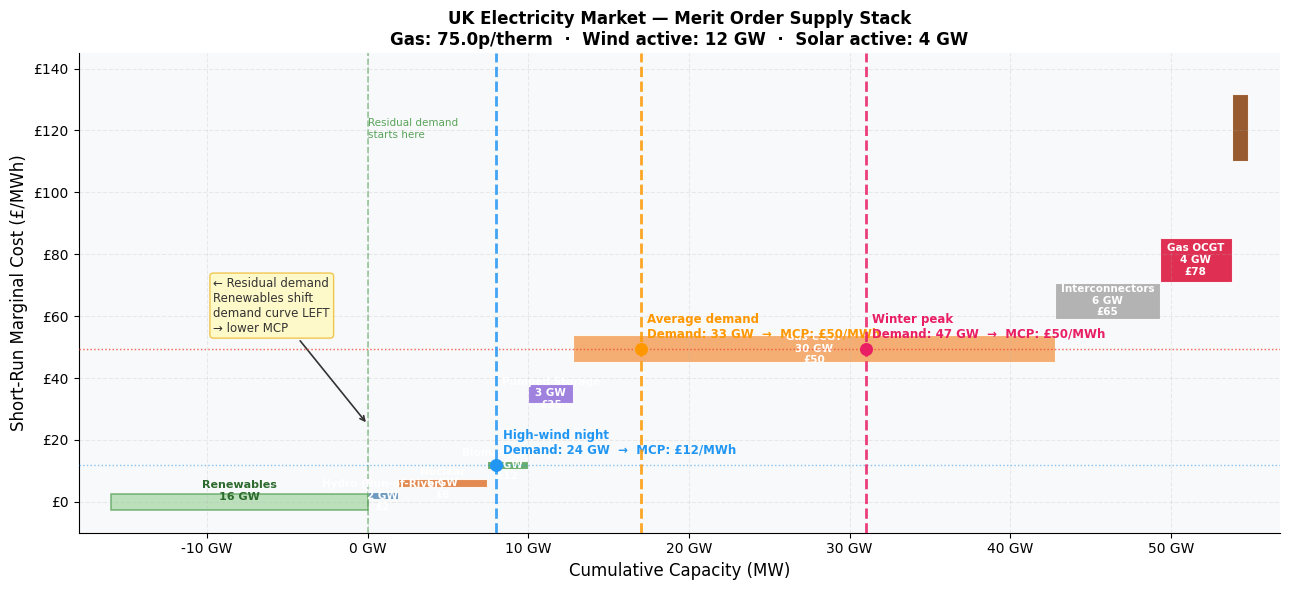

In [8]:
def plot_supply_stack(demand_scenarios, wind_mw=12_000, solar_mw=4_000):
    """
    Draw the merit order supply stack with demand scenario lines.
    
    demand_scenarios : list of (label, demand_mw)
    wind_mw          : total wind generation this hour
    solar_mw         : solar generation this hour
    """
    fig, ax = plt.subplots(figsize=(13, 6))

    # ── Draw the thermal stack (step function) ───────────────────────────────
    for _, g in fleet.iterrows():
        ax.barh(
            y          = g["srmc"],
            width      = g["capacity_mw"],
            left       = g["cum_start"],
            height     = max(g["srmc"] * 0.18, 2.5),    # bar height proportional to SRMC
            color      = g["color"],
            edgecolor  = "white",
            linewidth  = 0.8,
            alpha      = 0.88,
            label      = g["technology"],
        )
        # Label inside each bar
        if g["capacity_mw"] > 1500:
            ax.text(
                (g["cum_start"] + g["cum_end"]) / 2,
                g["srmc"],
                g['technology'] + '\n' + f"{g['capacity_gw']:.0f} GW\n£{g['srmc']:.0f}",
                ha="center", va="center", fontsize=7.5, color="white", fontweight="bold",
            )

    # ── Renewables block (left side, zero SRMC) ──────────────────────────────
    renewable_mw = wind_mw + solar_mw
    ax.barh(
        y=0, width=renewable_mw, left=-renewable_mw,
        height=5,
        color="#A8D8A8", edgecolor="#5AA45B", linewidth=1.2, alpha=0.75,
        label=f"Renewables ({renewable_mw/1000:.0f} GW active)",
    )
    ax.text(-renewable_mw / 2, 3.5, f"Renewables\n{renewable_mw/1000:.0f} GW",
            ha="center", va="center", fontsize=8, color="#2d6a2d", fontweight="bold")
    ax.axvline(0, color="#5AA45B", lw=1.2, ls="--", alpha=0.6)
    ax.text(0, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 100,
            "Residual demand\nstarts here", ha="left", fontsize=7.5, color="#5AA45B")

    # ── Demand scenario lines ─────────────────────────────────────────────────
    colours = ["#2196F3", "#FF9800", "#E91E63"]
    for (label, d_mw), colour in zip(demand_scenarios, colours):
        r   = dispatch(d_mw, wind_mw * 0.52, wind_mw * 0.48, solar_mw)
        mcp = r["clearing_price_mwh"]
        res = r["residual_demand_mw"]      # where the demand line sits on x-axis

        ax.axvline(res, color=colour, lw=2.0, ls="--", alpha=0.85, zorder=5)
        ax.axhline(mcp, color=colour, lw=1.0, ls=":", alpha=0.55, zorder=4)
        ax.scatter([res], [mcp], color=colour, s=70, zorder=6)
        ax.text(
            res + 400, mcp + 2.5,
            f"{label}\nDemand: {d_mw/1000:.0f} GW  →  MCP: £{mcp:.0f}/MWh",
            color=colour, fontsize=8.5, fontweight="bold", va="bottom",
        )

    # ── Axes & labels ──────────────────────────────────────────────────────────
    total_th = fleet["capacity_mw"].sum()
    ax.set_xlim(-renewable_mw - 2000, total_th + 2000)
    ax.set_ylim(-10, 145)
    ax.set_xlabel("Cumulative Capacity (MW)", fontsize=12)
    ax.set_ylabel("Short-Run Marginal Cost (£/MWh)", fontsize=12)
    ax.set_title(
        "UK Electricity Market — Merit Order Supply Stack\n"
        f"Gas: {GAS_P_THERM}p/therm  ·  Wind active: {wind_mw/1000:.0f} GW  ·  "
        f"Solar active: {solar_mw/1000:.0f} GW",
        fontsize=12, fontweight="bold",
    )
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"£{v:.0f}"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f} GW"))

    # Annotation explaining the key mechanic
    ax.annotate(
        "← Residual demand\nRenewables shift\ndemand curve LEFT\n→ lower MCP",
        xy=(0, 25), xytext=(-renewable_mw * 0.6, 55),
        arrowprops=dict(arrowstyle="->", color="#333", lw=1.2),
        fontsize=8.5, color="#333",
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFF9C4", ec="#F0C040", alpha=0.9),
    )

    plt.tight_layout()
    return fig


fig = plot_supply_stack(
    demand_scenarios=[
        ("High-wind night",     24_000),
        ("Average demand",      33_000),
        ("Winter peak",         47_000),
    ],
    wind_mw  = 12_000,
    solar_mw =  4_000,
)
plt.show()


## 9. Reading the chart — key insights

### What the chart shows

1. **The staircase = supply curve**  
   Generators ranked cheapest-first. The width of each step = how much capacity exists at that price.

2. **The demand line = which generator sets the price**  
   Slide the demand line left or right and watch the MCP change. The step it falls on is the marginal unit.

3. **The renewables block (green, left)**  
   In this snapshot, 16 GW of wind + solar is active. This shifts the effective residual demand ~16 GW to the left. Without renewables, demand lines would be 16 GW further right — likely hitting OCGT territory.

4. **Why CCGT sets the price so often**  
   CCGT sits in the middle of the stack at 30 GW capacity — the biggest single block. Most UK demand falls in a range where CCGT is the last unit needed. This is why **UK wholesale prices track gas prices so closely**.

5. **Inframarginal rent**  
   Every unit to the **left** of the marginal unit earns MCP but costs less. The gap between MCP (horizontal dotted line) and each unit's SRMC is inframarginal rent — received by nuclear, hydro, biomass every time CCGT is marginal.

---

### What changes the picture

| Event | Effect on stack |
|---|---|
| Gas price rises (e.g. 2022 crisis) | CCGT step moves up → MCP rises sharply |
| More wind installed | Green block widens → demand lines shift left → MCP falls |
| Nuclear plant off (outage) | Nuclear step disappears → residual demand on more expensive units |
| High interconnector imports | Interconnector block absorbs more demand at £65 → less OCGT needed |


## 10. Sensitivity analysis — wind output vs MCP

Let's sweep wind output from 0 to 40 GW and plot how MCP responds.  
This is the **Merit Order Effect (MOE)** — the mechanism by which renewable capacity suppresses wholesale prices.

**Key shape of the curve:**
- Flat at first (cheap baseload units absorb residual demand, still CCGT-marginal)
- Steps down at discrete thresholds as cheaper units stop being needed
- Drops to £0 when renewables exceed demand (curtailment zone)


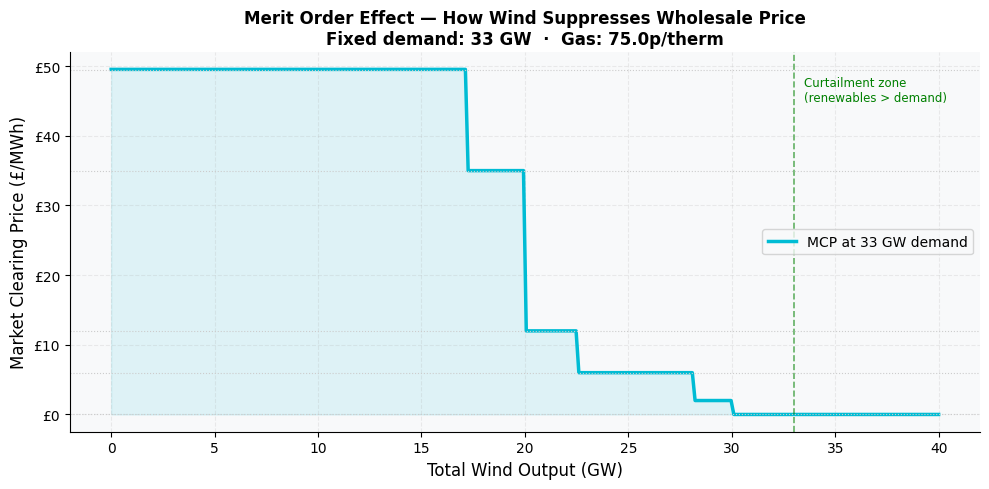

Notice the discrete 'steps' — MCP doesn't fall smoothly.
It stays flat while CCGT is marginal, then drops sharply when
wind is enough to push the residual demand into the pumped storage zone, etc.


In [9]:
DEMAND    = 33_000  # fixed demand for this sweep
wind_vals = np.linspace(0, 40_000, 300)
mcp_vals  = []

for wind in wind_vals:
    r = dispatch(DEMAND, wind * 0.52, wind * 0.48, solar_mw=3_000)
    mcp_vals.append(r["clearing_price_mwh"])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wind_vals / 1000, mcp_vals, color="#00BCD4", lw=2.5, label="MCP at 33 GW demand")
ax.fill_between(wind_vals / 1000, 0, mcp_vals, alpha=0.10, color="#00BCD4")

# Mark the curtailment threshold
ax.axvline(DEMAND / 1000, color="green", lw=1.2, ls="--", alpha=0.6)
ax.text(DEMAND / 1000 + 0.5, 45, "Curtailment zone\n(renewables > demand)",
        fontsize=8.5, color="green")

# Annotate the discrete steps
for step_price in [49.5, 35.0, 12.0, 6.0, 0.0]:
    ax.axhline(step_price, color="#ccc", lw=0.8, ls=":")

ax.set_xlabel("Total Wind Output (GW)", fontsize=12)
ax.set_ylabel("Market Clearing Price (£/MWh)", fontsize=12)
ax.set_title(
    "Merit Order Effect — How Wind Suppresses Wholesale Price\n"
    f"Fixed demand: {DEMAND/1000:.0f} GW  ·  Gas: {GAS_P_THERM}p/therm",
    fontsize=12, fontweight="bold",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"£{v:.0f}"))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Notice the discrete 'steps' — MCP doesn't fall smoothly.")
print("It stays flat while CCGT is marginal, then drops sharply when")
print("wind is enough to push the residual demand into the pumped storage zone, etc.")


## 11. Inframarginal rent — who earns what and why

Inframarginal rent is the profit above actual fuel cost earned by **all dispatched units except the marginal one**.

**Example at 33 GW demand, gas marginal (£49.5/MWh):**

| Generator | SRMC | MCP | Rent per MWh | Output | Rent per hour |
|---|---|---|---|---|---|
| Nuclear | £6 | £49.5 | £43.5 | 5,500 MW | ~£239k/hr |
| Hydro | £2 | £49.5 | £47.5 | 1,900 MW | ~£90k/hr |
| Biomass | £12 | £49.5 | £37.5 | 2,600 MW | ~£98k/hr |
| CCGT (marginal) | £49.5 | £49.5 | **£0** | — | £0 (it's the price-setter) |

This is why nuclear power stations print money during gas price spikes — they generate at £6 but sell at the gas-driven MCP.


In [10]:
# Compute inframarginal rent breakdown for the average scenario
r = dispatch(demand_mw=33_000, wind_offshore_mw=10_000, wind_onshore_mw=5_000, solar_mw=4_000)
mcp = r["clearing_price_mwh"]

print(f"Scenario: 33 GW demand, 19 GW renewables")
print(f"Market Clearing Price: £{mcp:.1f}/MWh")
print()
print(f"{'Technology':<22} {'SRMC':>8} {'MCP':>8} {'Rent/MWh':>10} {'Output(MW)':>12} {'Rent £k/hr':>12}")
print("─" * 78)

total_rent = 0
for d in r["dispatched"]:
    rent_per_mwh = mcp - d["srmc"]
    rent_ph      = rent_per_mwh * d["dispatched_mw"]
    total_rent  += rent_ph
    marker = " ← marginal" if d["srmc"] == mcp else ""
    print(
        f"  {d['technology']:<20} £{d['srmc']:>5.1f}  £{mcp:>5.1f}  "
        f"£{rent_per_mwh:>7.1f}/MWh  {d['dispatched_mw']:>10.0f}MW  "
        f"£{rent_ph/1000:>9.1f}k{marker}"
    )

print("─" * 78)
print(f"  {'TOTAL inframarginal rent':<20}{'':>32}  £{total_rent/1000:.1f}k/hr")
print()
print(f"  System cost (MCP × demand):  £{r['system_cost_ph']/1000:.1f}k/hr")
print(f"  Total fuel cost:             £{r['fuel_cost_ph']/1000:.1f}k/hr")
print(f"  Inframarginal rent:          £{r['inframarginal_rent_ph']/1000:.1f}k/hr")
print()
print("  → Buyers pay the system cost. Fuel providers receive the fuel cost.")
print("  → The gap (inframarginal rent) goes to generator owners as profit.")


Scenario: 33 GW demand, 19 GW renewables
Market Clearing Price: £49.5/MWh

Technology                 SRMC      MCP   Rent/MWh   Output(MW)   Rent £k/hr
──────────────────────────────────────────────────────────────────────────────
  Hydro (Run-of-River) £  2.0  £ 49.5  £   47.5/MWh        1900MW  £     90.3k
  Nuclear              £  6.0  £ 49.5  £   43.5/MWh        5500MW  £    239.4k
  Biomass (Drax)       £ 12.0  £ 49.5  £   37.5/MWh        2600MW  £     97.6k
  Pumped Storage       £ 35.0  £ 49.5  £   14.5/MWh        2800MW  £     40.7k
  Gas CCGT             £ 49.5  £ 49.5  £    0.0/MWh        1200MW  £      0.0k ← marginal
──────────────────────────────────────────────────────────────────────────────
  TOTAL inframarginal rent                                  £468.0k/hr

  System cost (MCP × demand):  £1634.5k/hr
  Total fuel cost:             £225.4k/hr
  Inframarginal rent:          £1409.0k/hr

  → Buyers pay the system cost. Fuel providers receive the fuel cost.
  → The gap 

## 12. Visualising inframarginal rent

A horizontal bar chart showing which generators earn the most rent per hour when CCGT is marginal.


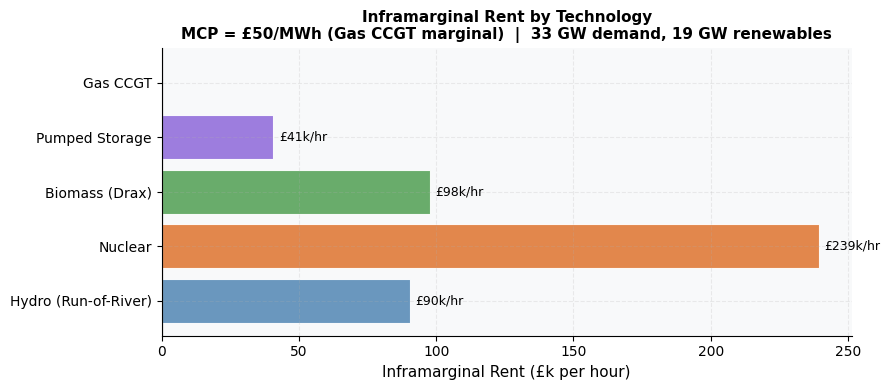

The CCGT earns £0 inframarginal rent — it IS the marginal unit.
Nuclear earns the most in absolute terms despite its low SRMC,
because it has large capacity AND a big gap to MCP.


In [11]:
r   = dispatch(demand_mw=33_000, wind_offshore_mw=10_000, wind_onshore_mw=5_000, solar_mw=4_000)
mcp = r["clearing_price_mwh"]

techs  = [d["technology"] for d in r["dispatched"]]
rent   = [(mcp - d["srmc"]) * d["dispatched_mw"] / 1000 for d in r["dispatched"]]  # £k/hr
colors = [d["color"] for d in r["dispatched"]]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(techs, rent, color=colors, edgecolor="white", linewidth=0.8, alpha=0.9)

for bar, val in zip(bars, rent):
    if val > 5:
        ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
                f"£{val:.0f}k/hr", va="center", fontsize=9)

ax.axvline(0, color="#333", lw=0.8)
ax.set_xlabel("Inframarginal Rent (£k per hour)", fontsize=11)
ax.set_title(
    f"Inframarginal Rent by Technology\nMCP = £{mcp:.0f}/MWh (Gas CCGT marginal)  |  "
    f"33 GW demand, 19 GW renewables",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

print("The CCGT earns £0 inframarginal rent — it IS the marginal unit.")
print("Nuclear earns the most in absolute terms despite its low SRMC,")
print("because it has large capacity AND a big gap to MCP.")


## 13. What happens when gas price changes?

Let's re-run the dispatch at three different gas prices and compare the stacks.  
This explains why the 2022 energy crisis was so severe — gas went from ~40p/therm to ~400p/therm,  
and because CCGT sets the UK price for ~50% of hours, MCP followed almost perfectly.


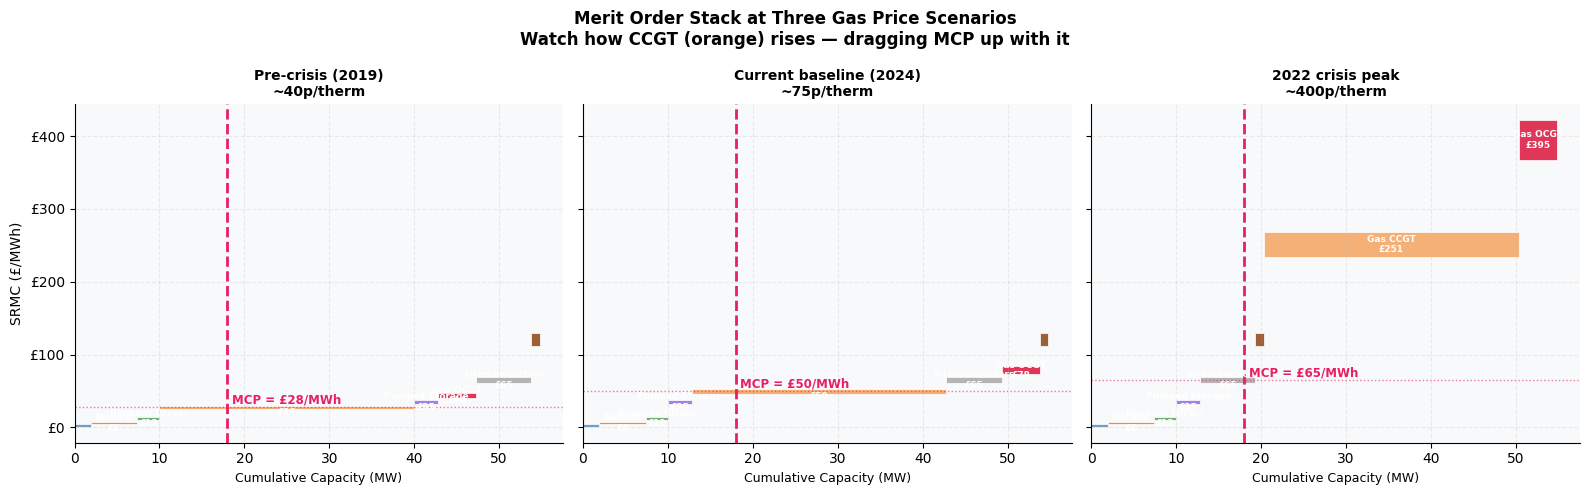

Key insight: the 2022 crisis didn't just affect gas plants.
Because CCGT sets the price for ~half of UK hours,
nuclear, wind, solar, hydro ALL earned MCP = ~£300-400/MWh.
That's the inframarginal rent windfall — which is why the
UK government introduced the Electricity Generator Levy (windfall tax).


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

gas_scenarios = [
    (40,  "Pre-crisis (2019)\n~40p/therm"),
    (75,  "Current baseline (2024)\n~75p/therm"),
    (400, "2022 crisis peak\n~400p/therm"),
]

for ax, (gas_p, title) in zip(axes, gas_scenarios):
    # Recalculate SRMC for this gas price
    ccgt_s = gas_srmc(gas_p, 0.55)
    ocgt_s = gas_srmc(gas_p, 0.35, 5.0)

    fleet_s = fleet.copy()
    fleet_s.loc[fleet_s["technology"] == "Gas CCGT", "srmc"] = ccgt_s
    fleet_s.loc[fleet_s["technology"] == "Gas OCGT", "srmc"] = ocgt_s
    fleet_s = fleet_s.sort_values("srmc").reset_index(drop=True)
    fleet_s["cum_start"] = fleet_s["capacity_mw"].cumsum().shift(1).fillna(0)
    fleet_s["cum_end"]   = fleet_s["capacity_mw"].cumsum()

    for _, g in fleet_s.iterrows():
        ax.barh(
            y=g["srmc"], width=g["capacity_mw"], left=g["cum_start"],
            height=max(g["srmc"] * 0.14, 4),
            color=g["color"], edgecolor="white", linewidth=0.6, alpha=0.85,
        )
        if g["capacity_mw"] > 2000:
            ax.text(
                (g["cum_start"] + g["cum_end"]) / 2, g["srmc"],
                f"{g['technology']}\n£{g['srmc']:.0f}",
                ha="center", va="center", fontsize=6.5, color="white", fontweight="bold",
            )

    # 33 GW demand line
    DEMAND = 33_000
    WIND   = 12_000
    SOLAR  =  3_000
    resid  = max(0, DEMAND - WIND - SOLAR)
    
    # Find MCP for this gas price
    remaining = resid
    mcp_s = 0.0
    for _, g in fleet_s.iterrows():
        if remaining <= 0:
            break
        qty = min(g["capacity_mw"], remaining)
        remaining -= qty
        mcp_s = g["srmc"]

    ax.axvline(resid, color="#E91E63", lw=2, ls="--", label=f"33 GW demand")
    ax.axhline(mcp_s, color="#E91E63", lw=1, ls=":", alpha=0.6)
    ax.text(resid + 500, mcp_s + 5, f"MCP = £{mcp_s:.0f}/MWh",
            color="#E91E63", fontsize=8.5, fontweight="bold")

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Cumulative Capacity (MW)", fontsize=9)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"£{v:.0f}"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}"))

axes[0].set_ylabel("SRMC (£/MWh)", fontsize=10)
fig.suptitle(
    "Merit Order Stack at Three Gas Price Scenarios\n"
    "Watch how CCGT (orange) rises — dragging MCP up with it",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

print("Key insight: the 2022 crisis didn't just affect gas plants.")
print("Because CCGT sets the price for ~half of UK hours,")
print("nuclear, wind, solar, hydro ALL earned MCP = ~£300-400/MWh.")
print("That's the inframarginal rent windfall — which is why the")
print("UK government introduced the Electricity Generator Levy (windfall tax).")


## 14. Summary — the key ideas

### Merit order dispatch in one sentence
*Generators are ranked by Short-Run Marginal Cost and dispatched cheapest-first until demand is met; the last unit needed sets the price for everyone.*

### The five concepts you now understand

| Concept | What it means |
|---|---|
| **SRMC** | Variable cost of generating one more MWh: fuel/efficiency + O&M |
| **Merit order stack** | Generators lined up cheapest-first — the supply curve |
| **Market Clearing Price** | SRMC of the marginal (last) unit dispatched — everyone receives this |
| **Inframarginal rent** | Profit above fuel cost earned by all inframarginal (cheaper) units |
| **Merit Order Effect** | Renewables bid £0 → displace expensive units → lower MCP for all buyers |

### Why this matters for UK electricity

- **Gas dominance**: CCGT sits in the middle of the stack at 30 GW — it sets the price for ~50% of hours. This is why UK electricity prices track NBP gas prices so closely.
- **2022 energy crisis**: Gas at ~400p/therm pushed CCGT SRMC above £250/MWh → MCP followed → huge inframarginal rent for nuclear/wind → windfall tax.
- **Energy transition**: Every additional GW of offshore wind shifts demand lines left → displaces CCGT hours → structurally lower average MCP → good for consumers, bad for thermal generators' revenues.

### What this model doesn't capture (yet)
- **Unit commitment**: minimum output levels, start-up costs, minimum up/down time constraints
- **CO₂ pricing**: UK ETS ~£50/t adds ~£8/MWh to CCGT SRMC and more to coal
- **Battery storage**: dispatches based on price arbitrage, not pure SRMC
- **Interconnectors**: in reality prices equilibrate across borders dynamically
- **Ancillary services**: balancing mechanism, frequency response — separate markets
